# 📝 Instrucciones: Sistema de Agrupación de Casas (Clustering)

El objetivo de este proyecto es clasificar casas según su ubicación geográfica (**Latitud y Longitud**) y el **Ingreso Medio** de la zona. Utilizaremos el conjunto de datos *California Housing* (Censo de 1990) para realizar un proceso mixto de aprendizaje no supervisado y supervisado.

---

## 📂 Paso 1: Carga del conjunto de datos
El dataset contiene información por grupos de bloques censales. Para este análisis, nos enfocaremos únicamente en las variables: `Latitude`, `Longitude` y `MedInc`.

* **Fuente:** [housing.csv](https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv)
* **Tarea:** 1. Cargar el dataset.
    2. Filtrar las columnas mencionadas.
    3. Dividir el conjunto en **train** y **test**.

---

## 🤖 Paso 2: Construye un K-Means
Implementaremos un algoritmo de agrupamiento para segmentar las casas.

1. **Modelado:** Clasifica los datos en **6 clusters** utilizando el modelo `K-Means`.
2. **Asignación:** Añade una nueva columna llamada `cluster` a tu DataFrame.
3. **Visualización:** Genera un diagrama de puntos (scatter plot) utilizando la latitud y longitud, coloreando los puntos según su cluster.
4. **Análisis:** Describe los patrones geográficos observados.

---

## 🔮 Paso 3: Predice con el conjunto de test
Valida la consistencia del modelo:
1. Utiliza el modelo entrenado para predecir los clusters en el conjunto de **test**.
2. Añade estos puntos al gráfico anterior para verificar si la distribución es coherente con los datos de entrenamiento.

---

## 📈 Paso 4: Entrena un modelo de clasificación supervisada
Una vez que el K-Means ha "etiquetado" nuestros datos, convertiremos el problema en uno de aprendizaje supervisado.

1. **Objetivo:** Predecir el `cluster` (etiqueta generada) utilizando las variables originales.
2. **Tarea:** Elige un modelo de clasificación (ej. Random Forest, Decision Tree), entrénalo y obtén las métricas de evaluación.
3. **Reflexión:** ¿Qué tan bien aprendió el modelo supervisado a replicar la lógica del K-Means?

---

## 💾 Paso 5: Guarda los modelos
Finalmente, exporta ambos modelos (el de Clustering y el de Clasificación) utilizando librerías como `joblib` o `pickle` para su uso futuro.

---
> **Nota:** Este flujo es una técnica poderosa cuando contamos con datos no etiquetados: usamos **No Supervisado** para crear etiquetas y **Supervisado** para automatizar la clasificación futura.

In [ ]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [65]:
# Cargamos el dataset de casas
df=pd.read_csv("../data/raw/housing.csv")
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [66]:
#chekamos la info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [67]:
# Nos Piden enfocarnos en las columnas de latitud, longitud e ingreso medio
df = df[['Latitude', 'Longitude', 'MedInc']]
# Ahora Hacemos un describe para ojear si hay outliers en latitud, longitud e ingreso medio
df.describe(include = 'all')

,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


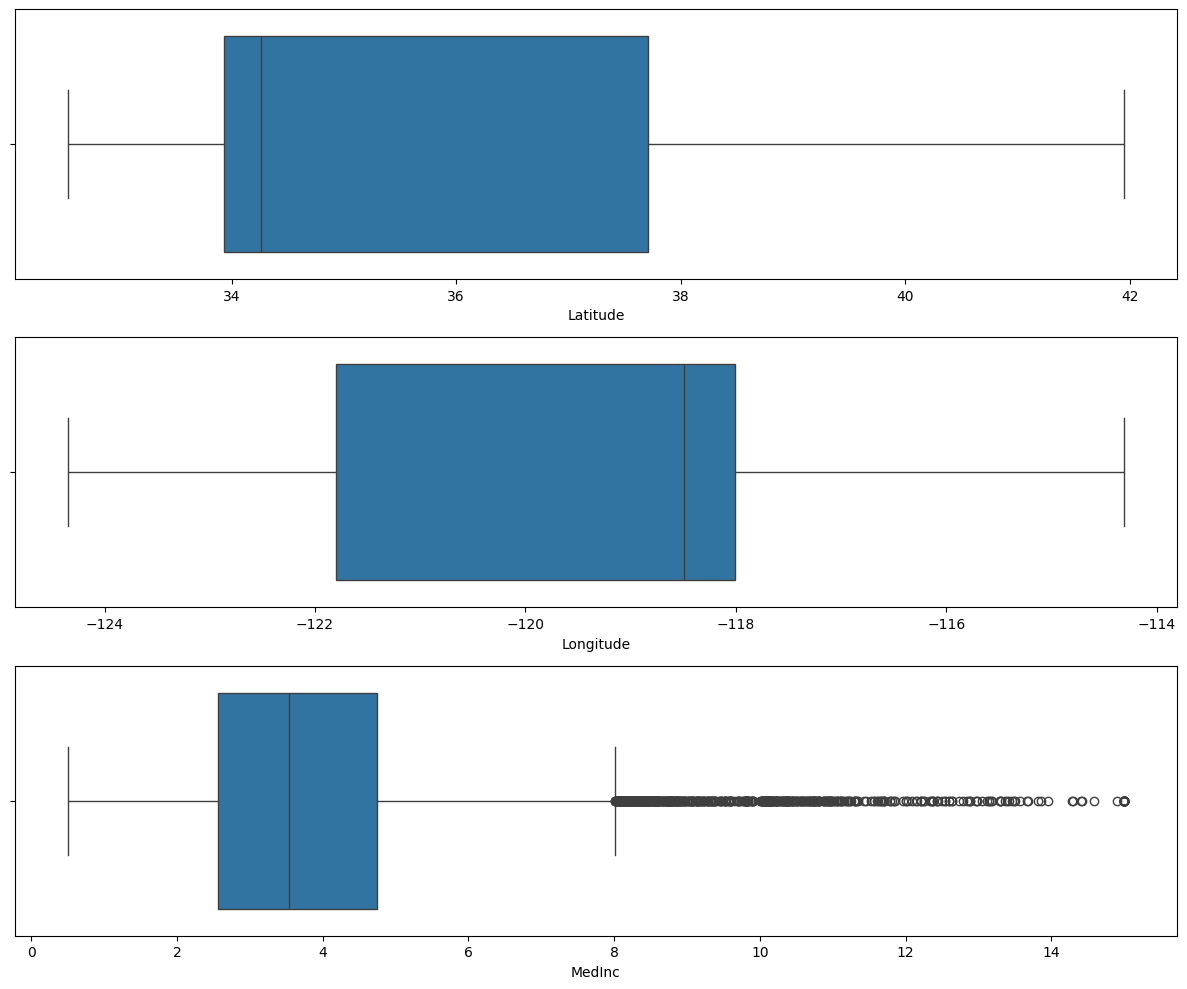

In [ ]:
#Vamos a hacer un multigrafico de caja y bigotes para hechar un primer vistazo a las 3 variables numericas
fig = plt.figure(figsize = (12, 10))

# Creamos el grid de 3x1
axis = gridspec.GridSpec(3, 1, figure = fig)

axis0 = fig.add_subplot(axis[0]); sns.boxplot(data = df, orient="h" , x = 'Latitude', ax = axis0)
axis1 = fig.add_subplot(axis[1]); sns.boxplot(data = df, orient="h" , x = 'Longitude', ax = axis1)
axis2 = fig.add_subplot(axis[2]); sns.boxplot(data = df, orient="h" , x = 'MedInc', ax = axis2)


# Ajustar Layout para que no se solapen los titulos
plt.tight_layout()
plt.show()

## Analisis Hasta Ahora:
* Tenemos un dataframe de datos de reviews con 20640 filas y 9 columnas.
* 9 Columnas son float pero el enunciado nos pide `Latitude`, `Longitude`, `MedInc` asi que nos quedamos con 3 float.
* No tenemos un target como tal sino que nuestra mision es clasificar segun las 3 variables que vimos antes.
* Podemos ver que `MedInc` tiene bastantes outliers, `Latitude` y `Longitude` no tienen.

In [ ]:
#Dividimos en entrenamiento y prueba (80/20)
X_train, X_test = train_test_split(df, test_size = 0.2, random_state = 42)
X_train.head()

,Latitude,Longitude,MedInc
14196,32.71,-117.03,3.2596
8267,33.77,-118.16,3.8125
17445,34.66,-120.48,4.1563
14265,32.69,-117.11,1.9425
2271,36.78,-119.80,3.5542


In [70]:
#Escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Aplicamos el modelo kmeans como indica el ejercicio yle decimos que son 6 clusteres.
model_km = KMeans(n_clusters = 6, random_state = 42)

# Entrenamos
model_km.fit(X_train_scaled)

# Añadimos la columna cluster para poder visualizar los clusteres en el scatterplot
X_train['cluster'] = model_km.labels_

In [72]:
# Predecimos los clusters para el conjunto de test
X_test['cluster'] = model_km.predict(X_test_scaled)

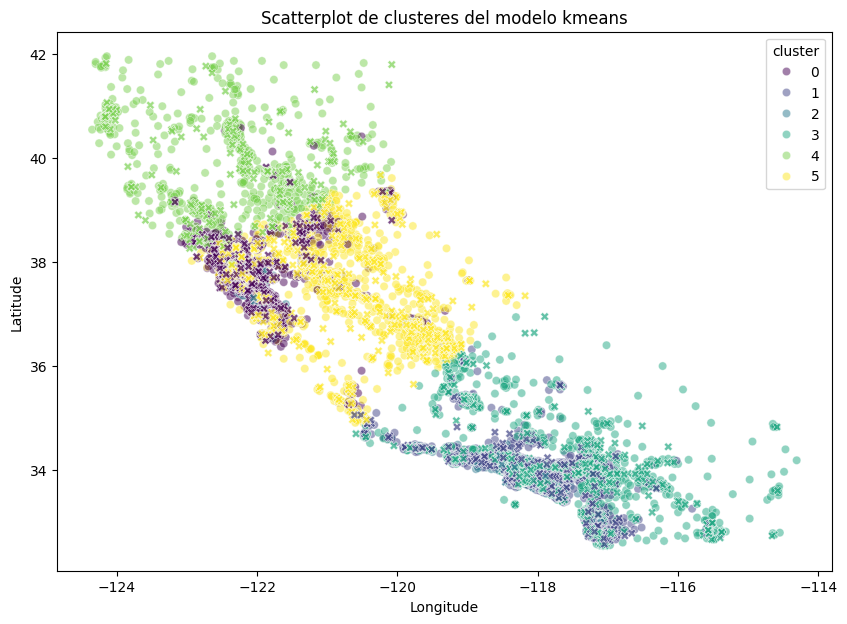

In [ ]:
plt.figure(figsize = (10, 7))
# Graficamos el conjunto de entrenamiento
sns.scatterplot(data = X_train, x = 'Longitude', y = 'Latitude', hue = 'cluster', palette = 'viridis', alpha = 0.5)
# Para ver si hay coherencia con los datos de test, los graficamos tambien pero con una marker = X
sns.scatterplot(data = X_test, x = 'Longitude', y = 'Latitude', hue = 'cluster', palette = 'viridis', marker = 'X', legend = False, alpha = 0.7)
plt.title('Scatterplot de clusteres del modelo kmeans')
plt.show()

## Interpretacion del grafico.
* Como estamos hablando de latitud y longitud, basicamente lo que estamos viendo es un mapa con su norte,sut,este y oeste.
* A primera vista vemos tres separaciones principales el cluster 5(amarillo) en el centro, 4(Verde) en el noroeste y 3(Verde Azulado) en el sur y un poco al medio, estos 3 representan la mayoria de los datos del dataset.
* Los otros tres clusteres(0,1 y 2) como estamos viendo se fusionan o posicionan junto con los otros clusteres, esto represta que como metimos una tercer variable `MedInc` el modelo los esta separando, es decir sin esta tercer variable el modelo no podria diferencialos, ademas el hecho que visualicemos el grafico en 2D tambien dificulta euna interpretacion visual cuando hay 3 variables.
* Los 3 clusteres que podriamos decir son casas de alto valor economico se ven reflejadas fusionandose de la siguiente manera:
 * El cluster 0(Morado) con la parte noroeste del cluster 5(amarillo) indicandonos que hay una zona muy especifica de aca donde hay disparidad en el valor de las casas.
 * El cluster 1(no me se el color asi que lo pongo en exadecimal #9fa1c2) se distribuye bien con el cluster 3 Aunque un poco hacia abajo, Viendo como es california y tratando de ver esto como un mapa esto representarian zonas costeras y de playas.
* Las "X"(los datos de prueba), dentro de todo se acoplan bien al grupo u color que deberian.

## Ahora que Sigue?
Pues ya que tenemos los clusteres vamos al paso 4, entrenar un modelo que aprenda reglas y decirnos a que cluster pertenece. Vamos a usar un ramdon forest por ejemplo, No vamos a usar un GridSearch porque no hace falta alterar muchos los parametros como nuestro target nacio de los propios datos se he de esperar que el score sea alto de por si.

In [74]:
#Separamos el target 
X_train_sup = X_train.drop('cluster', axis=1)
y_train_sup = X_train['cluster']

X_test_sup = X_test.drop('cluster', axis=1)
y_test_sup = X_test['cluster']

#Entrenamos el modelo supervisado
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_sup, y_train_sup)

# Evaluamos
model_preds = model_rf.predict(X_test_sup)
print(classification_report(y_test_sup, model_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       557
           1       1.00      1.00      1.00       897
           2       1.00      0.97      0.99       116
           3       1.00      1.00      1.00      1397
           4       0.98      0.99      0.99       246
           5       0.99      0.99      0.99       915

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



In [75]:
#Podemos intentar validar el modelo con un cross-validation para ver si el modelo es robusto o no
scores = cross_val_score(model_rf, X_train_sup, y_train_sup, cv=5)

print(f"Precision media: {scores.mean():.4f}")
print(f"Desviación estándar (Robustez): {scores.std():.4f}")

Precision media: 0.9921
Desviación estándar (Robustez): 0.0014


## Conclusiones Finales:
* Vimos como el kmeans logro clasificar relativamente bien a las casas del dataframe basado en california, en  6 grupos, 3 que representan la mayoria, y otros 3 que representan la diferenciancion que hace la variable `MedInc` aunque esten ubicada 2 casas en una misma zona.
* Tambien el modelo ramdom forest logro predecir bien los 6 grupos con una presicion de 0.99 ademas de que se valido con el cross-val, esto era de esperarse pues los datos de grupos o los clusteres nacieron de los propios datos. Por lo que para evluar correctamente el rendimiento del el modelo se le tienen que poner nuevos datos fuera de este dataframe.

In [76]:
#Guardamos ambos modelos el kmeans y el ramdomforest
model_pack = {
    'model_km': model_km,
    'model_rf': model_rf,
    'x_train_no_sup': X_train_scaled,
    'x_test_no_sup': X_test_scaled,
    'x_train_sup': X_train_sup,
    'x_test_sup': X_test_sup,
    'y_train_sup': y_train_sup,
    'y_test': y_test_sup
}
path = f"../data/processed/models/k-means/"
if not os.path.exists(path):
    os.makedirs(path)
#  Guardamos el paquete
joblib.dump(model_pack, f'{path}models_pack.pkl')

['../data/processed/models/k-means/models_pack.pkl']